In [1]:
import math
def is_number(string):
    """Checks if a string is a number (integer or float)."""
    try:
        value = float(string)
        # check if string is NaN
        if math.isnan(value):
            return False
        else:
            return True
    except ValueError:
        return False
def convert_to_kelvin(temp):
    try:
        value = float(temp)
        if value < 100:
            return value + 273.15
        elif value >= 250:
            return value
        else:
            return 298
    except ValueError:
        return 298
R_gas = 1.9872042586408e-3 # kcal/(mol·K)
def calculate_affinity(row):
    delta_g = row['delta_g']
    kd = row['KD(M)']
    temp = row['Temperature(K)']
    if is_number(delta_g):
        return -float(delta_g)
    elif is_number(kd):
        kd_value = float(kd)
        affinity = -R_gas * temp * math.log(kd_value)
        return affinity
    else:
        return "unclear"
def calculate_affinity_default_temp(KD_M):
    return -R_gas * 298 * math.log(KD_M)
def is_close(a, b, rel_tol=1e-03, abs_tol=1e-3):
    return abs(a-b) <= max(rel_tol * max(abs(a), abs(b)), abs_tol)
def unit_convert_to_M(value, unit):
    """Convert various units to Molar (M)."""
    if unit == 'mM':
        return value * 1e-3
    elif unit == 'uM':
        return value * 1e-6
    elif unit == 'nM':
        return value * 1e-9
    elif unit == 'pM':
        return value * 1e-12
    elif unit == 'fM':
        return value * 1e-15
    else:
        return value  # assume already in M

import urllib.request
from pathlib import Path
from tqdm import tqdm
import time

def download_pdb(pdb_id, output_dir):
    """
    Download a PDB file from RCSB PDB.
    
    Args:
        pdb_id: 4-character PDB ID (case-insensitive)
        output_dir: Path object for output directory
    
    Returns:
        True if successful, False otherwise
    """
    pdb_id = pdb_id.upper()
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    output_path = output_dir / f"{pdb_id}.pdb"
    
    # Skip if already exists
    if output_path.exists():
        return True
    
    try:
        urllib.request.urlretrieve(url, str(output_path))
        return True
    except Exception as e:
        print(f"Failed to download {pdb_id}: {e}")
        return False

# Curate new database from SAbDab and update effective samples

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

## Clean SAbDab

In [3]:
sabdab_df = pd.read_csv('/Users/songzhihenry/Downloads/sabdab_summary_all.tsv', sep='\t')
sabdab_df

,pdb,Hchain,Lchain,model,antigen_chain,antigen_type,antigen_het_name,antigen_name,short_header,date,...,scfv,engineered,heavy_subclass,light_subclass,light_ctype,affinity,delta_g,affinity_method,temperature,pmid
0,9bop,A,B,0,S,protein,NaN,virion spike glycoprotein gp1,VIRAL PROTEIN/IMMUNE SYSTEM,11/05/25,...,False,True,IGHV1,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN
1,9bop,M,N,0,S | V,protein | protein,NA | NA,virion spike glycoprotein gp1 | virion spike g...,VIRAL PROTEIN/IMMUNE SYSTEM,11/05/25,...,False,True,IGHV1,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN
2,9bop,O,P,0,T | W,protein | protein,NA | NA,virion spike glycoprotein gp1 | virion spike g...,VIRAL PROTEIN/IMMUNE SYSTEM,11/05/25,...,False,True,IGHV1,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN
3,9bop,C,D,0,T,protein,NaN,virion spike glycoprotein gp1,VIRAL PROTEIN/IMMUNE SYSTEM,11/05/25,...,False,True,IGHV1,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN
4,9bop,E,F,0,U,protein,NaN,virion spike glycoprotein gp1,VIRAL PROTEIN/IMMUNE SYSTEM,11/05/25,...,False,True,IGHV1,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19883,6ejm,H,h,0,B,protein,NaN,cd81 antigen,CELL ADHESION,09/22/17,...,True,True,unknown,unknown,unknown,8.600000e-10,-12.367557,SPR,NaN,TBD
19884,7lo6,J,I,0,C,protein,NaN,envelope glycoprotein bg505 sosip.664 gp120,VIRAL PROTEIN/IMMUNE SYSTEM,02/09/21,...,False,True,IGHV1,IGKV3,Kappa,NaN,NaN,NaN,NaN,NaN
19885,3vi3,H,L,0,D,protein,NaN,integrin beta-1,CELL ADHESION/IMMUNE SYSTEM,09/21/11,...,False,True,IGHV1,IGKV2,Kappa,NaN,NaN,NaN,NaN,NaN
19886,6zdg,F,G,0,D,protein,NaN,spike glycoprotein,VIRAL PROTEIN,06/14/20,...,False,True,IGHV3,IGKV1,Kappa,NaN,NaN,NaN,NaN,NaN


In [4]:
sabdab_df['antigen_type'].unique().tolist()

['protein',
 'protein | protein',
 nan,
 'protein | protein | protein',
 'peptide',
 'protein | peptide',
 'carbohydrate',
 'nucleic-acid',
 'protein | nucleic-acid',
 'protein | protein | protein | protein',
 'protein | protein | protein | protein | protein',
 'Hapten',
 'peptide | protein',
 'protein | peptide | peptide',
 'peptide | peptide',
 'protein | protein | peptide',
 'protein | peptide | protein',
 'protein | protein | protein | peptide',
 'unknown',
 'carbohydrate | protein | protein',
 'peptide | peptide | peptide',
 'peptide | protein | protein',
 'carbohydrate | protein',
 'nucleic-acid | nucleic-acid',
 'nucleic-acid | nucleic-acid | nucleic-acid']

In [5]:
# filter out rows where 'affinity' or 'delta_g' are not numbers, not NaN, not blank
filtered_df = sabdab_df[
    sabdab_df['affinity'].apply(is_number) |
    sabdab_df['delta_g'].apply(is_number)
]
#filter out antigen type that contains nan, 'carbohydrate', 'nucleic-acid', 'Hapten', 'unknown'
filtered_df = filtered_df[
    (filtered_df['antigen_type'].str.contains('protein', na=False)) |
    (filtered_df['antigen_type'].str.contains('peptide', na=False))
    
]
# change filtered_df columns' names to other names. pdb->PDB, affinity->KD(M), antigen_chain->Receptor Chains
filtered_df = filtered_df.rename(columns={'pdb': 'PDB', 'affinity': 'KD(M)', 'antigen_chain': 'Receptor Chains','method':'Structure Method'})
#filtered_df['Source Data Set'] = 'SAbDab'
# create a new column 'Temperature(K)' and check if column of 'temperature' value: if it's below 100, add 273.15 to convert to Kelvin; if it's above 250, keep the value as is; if it's NaN or blank, assign 298.15
filtered_df['Temperature(K)'] = filtered_df['temperature'].apply(convert_to_kelvin)
# create a new column 'Ligand Chains', assign the values from column Hchain and Lchain concatenated with comma
filtered_df['Ligand Chains'] = filtered_df['Hchain'].fillna('') + ',' + filtered_df['Lchain'].fillna('')
filtered_df['Ligand Chains'] = filtered_df['Ligand Chains'].str.strip(',')

filtered_df['affinity'] = filtered_df.apply(calculate_affinity, axis=1)
filtered_df = filtered_df.drop(columns=['Hchain', 'Lchain', 'temperature', 'delta_g', 'antigen_type', 'antigen_het_name', 'model', 'heavy_species', 'light_species',
                                        'antigen_name', 'short_header', 'date','compound','scfv','engineered','heavy_subclass','affinity_method','antigen_species',
                                        'organism', 'authors','resolution', 'r_free', 'r_factor', 'light_subclass','light_ctype', 'pmid'])
# drop duplicated PDB ids in filtered_df
filtered_df = filtered_df.drop_duplicates(subset=['PDB'], keep='first')
# change column PDB to uppercase
filtered_df['PDB'] = filtered_df['PDB'].str.upper()

In [6]:
filtered_df = filtered_df.reset_index(drop=True)
filtered_df

,PDB,Receptor Chains,Structure Method,KD(M),Temperature(K),Ligand Chains,affinity
0,6FE4,A,X-RAY DIFFRACTION,9.600000e-09,298.00,F,10.938139
1,5W08,C,X-RAY DIFFRACTION,4.000000e-08,298.00,"K,L",10.092596
2,2NY3,A,X-RAY DIFFRACTION,8.150000e-07,298.00,"D,C",8.302506
3,6H7O,B,X-RAY DIFFRACTION,1.400000e-10,298.00,D,13.443087
4,1NCA,N,X-RAY DIFFRACTION,8.300000e-09,298.15,"H,L",11.020000
...,...,...,...,...,...,...,...
595,4ZFG,A,X-RAY DIFFRACTION,5.000000e-09,298.00,"H,L",11.324631
596,5SY8,O,X-RAY DIFFRACTION,1.120000e-11,298.00,"H,L",14.939540
597,3IDX,G,X-RAY DIFFRACTION,4.040000e-09,298.00,"H,L",11.450945
598,4PS4,A,X-RAY DIFFRACTION,5.700000e-12,298.00,"H,L",15.339731


## Checkout how new samples overlap with the current database

In [7]:
wt_df = pd.read_pickle('./saved_tables/unmutant_complex_table_filtered.pkl').drop(columns=['filesize'])
wt_df

,PDB,KD(M),paths,affinity,Structure Method,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.334439,X-RAY DIFFRACTION,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.863883,X-RAY DIFFRACTION,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,15.910114,X-RAY DIFFRACTION,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,X-RAY DIFFRACTION,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.709835,X-RAY DIFFRACTION,A,D
...,...,...,...,...,...,...,...
12940,3TJH,4.000000e-06,../../PDB/ATLAS/3TJH.pdb,7.364124,X-RAY DIFFRACTION,"A, C","D, E"
12952,3TF7,3.000000e-04,../../PDB/ATLAS/3TF7.pdb,4.806077,X-RAY DIFFRACTION,"A, C","D, E"
12984,4PRI,9.320000e-05,../../PDB/ATLAS/4PRI.pdb,5.498712,X-RAY DIFFRACTION,"A, C","D, E"
12999,3DXA,3.000000e-07,../../PDB/ATLAS/3DXA.pdb,8.898818,X-RAY DIFFRACTION,"A, C","D, E"


In [8]:
current_pdb_list = [pdb.lower() for pdb in wt_df['PDB'].unique()]
set_1 = set(filtered_df['PDB'].str.lower().unique())
set_2 = set(current_pdb_list)
# check how many pdb set_1 and set_2 are sharing
shared_pdbs = set_1.intersection(set_2)
diff_pdbs = set_1 - set_2
len(set_1),len(set_2),len(shared_pdbs), len(diff_pdbs)

(600, 3027, 598, 2)

In [9]:
old_affinities = []
new_affinities = []
for pdb in shared_pdbs:
    affinity_new = filtered_df[filtered_df['PDB'].str.lower() == pdb]['affinity'].values[0]
    affinity_old = wt_df[wt_df['PDB'].str.lower() == pdb]['affinity'].values[0]
    if not is_close(affinity_new, affinity_old):
        print(f"PDB: {pdb}, New affinity: {affinity_new}, Old affinity: {affinity_old}")
        # update the mean affinity value to wt_df
        wt_df.loc[wt_df['PDB'].str.lower() == pdb, 'affinity'] = (affinity_old + affinity_new) / 2
        old_affinities.append(affinity_old)
        new_affinities.append(affinity_new)

PDB: 1cz8, New affinity: 14.12, Old affinity: 13.436352129652795
PDB: 2b2x, New affinity: 11.95, Old affinity: 12.047940824976285
PDB: 2p45, New affinity: 9.61, Old affinity: 9.620467509233137
PDB: 2hkf, New affinity: 8.89, Old affinity: 8.879390368106684
PDB: 1yy9, New affinity: 11.78, Old affinity: 12.112139388037868
PDB: 1mlc, New affinity: 9.6, Old affinity: 11.39465915869219
PDB: 2jel, New affinity: 11.49, Old affinity: 11.621462141435702
PDB: 3idx, New affinity: 11.450944611411623, Old affinity: 8.912378370152943
PDB: 3eyu, New affinity: 10.21, Old affinity: 10.220944453355312
PDB: 2wub, New affinity: 9.3, Old affinity: 9.309497117051375
PDB: 1hez, New affinity: 9.32, Old affinity: 9.32958327619116
PDB: 2nyy, New affinity: 15.72, Old affinity: 13.412836614558438
PDB: 3eys, New affinity: 7.4, Old affinity: 7.408215459611634
PDB: 4krl, New affinity: 9.997047185087938, Old affinity: 9.08070839808894
PDB: 1pz5, New affinity: 7.8, Old affinity: 7.364123533368726
PDB: 1vfb, New affinit

## Checkout mismatch values' correlation

Pearson correlation coefficient (r): 0.8448
P-value: 4.9001e-11
R² (coefficient of determination): 0.7137


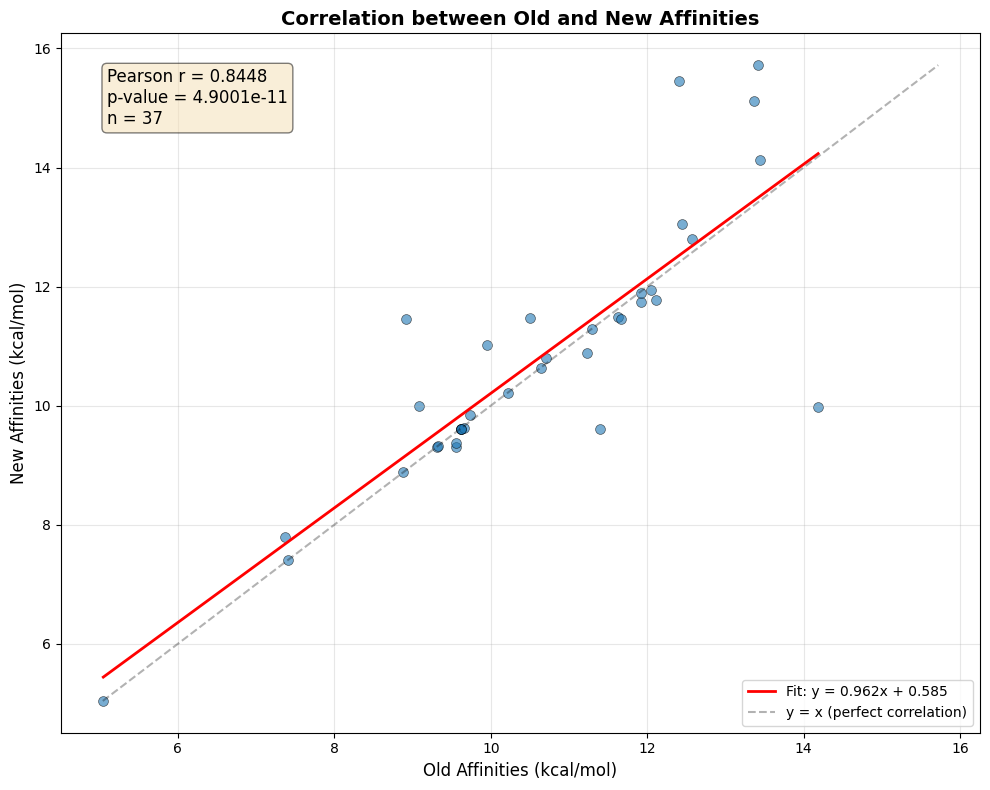

In [10]:
# Compute Pearson correlation coefficient
pearson_r, p_value = stats.pearsonr(old_affinities, new_affinities)

# Compute linear regression for fitting line
slope, intercept = np.polyfit(old_affinities, new_affinities, 1)
fit_line = np.poly1d([slope, intercept])

# Create x values for smooth fitting line
x_fit = np.linspace(min(old_affinities), max(old_affinities), 100)
y_fit = fit_line(x_fit)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(old_affinities, new_affinities, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')

# Add diagonal reference line (perfect correlation)
min_val = min(min(old_affinities), min(new_affinities))
max_val = max(max(old_affinities), max(new_affinities))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='y = x (perfect correlation)')

# Add text box with statistics
textstr = f'Pearson r = {pearson_r:.4f}\np-value = {p_value:.4e}\nn = {len(old_affinities)}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('Old Affinities (kcal/mol)', fontsize=12)
plt.ylabel('New Affinities (kcal/mol)', fontsize=12)
plt.title('Correlation between Old and New Affinities', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Pearson correlation coefficient (r): {pearson_r:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"R² (coefficient of determination): {pearson_r**2:.4f}")

## Update new samples from SAbDab database

In [11]:
# get filtered_df rows column 'PDB' in diff_pdbs
new_pdb_df = filtered_df[filtered_df['PDB'].str.lower().isin(diff_pdbs)]
# add column paths by add f'../../PDB/updated_pdb/{pdb_id}.pdb' for each pdb_id in new_pdb_df['PDB']
new_pdb_df['paths'] = new_pdb_df['PDB'].apply(lambda pdb_id: f'../../PDB/updated_pdb/{pdb_id}.pdb')
# check paths in new_pdb_df exist
for path in new_pdb_df['paths']:
    if not os.path.exists(path):
        print(f"Path does not exist: {path}")

/var/folders/7y/24kmvp416lg3pshfs_b4qrcm0000gq/T/ipykernel_72698/3399002647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_pdb_df['paths'] = new_pdb_df['PDB'].apply(lambda pdb_id: f'../../PDB/updated_pdb/{pdb_id}.pdb')


In [12]:
new_pdb_df

,PDB,Receptor Chains,Structure Method,KD(M),Temperature(K),Ligand Chains,affinity,paths
28,1ZEA,A,X-RAY DIFFRACTION,6.000000e-06,298.0,"H,L",7.123876,../../PDB/updated_pdb/1ZEA.pdb
408,6DF1,A,X-RAY DIFFRACTION,2.770000e-07,298.0,"H,L",8.946058,../../PDB/updated_pdb/6DF1.pdb


In [13]:
# combine wt_df and new_pdb_df to form updated_wt_df
updated_wt_df = pd.concat([wt_df, new_pdb_df], ignore_index=True)
updated_wt_df = updated_wt_df.drop(columns=['Temperature(K)','Structure Method'])
#updated_wt_df.to_pickle('./saved_tables/updated_unmutant_complex_table.pkl')
updated_wt_df

,PDB,KD(M),paths,affinity,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.334439,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.863883,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,15.910114,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.709835,A,D
...,...,...,...,...,...,...
3024,4PRI,9.320000e-05,../../PDB/ATLAS/4PRI.pdb,5.498712,"A, C","D, E"
3025,3DXA,3.000000e-07,../../PDB/ATLAS/3DXA.pdb,8.898818,"A, C","D, E"
3026,3O4L,1.070000e-05,../../PDB/ATLAS/3O4L.pdb,6.781148,"A, C","D, E"
3027,1ZEA,6.000000e-06,../../PDB/updated_pdb/1ZEA.pdb,7.123876,"H,L",A


# Checkout sample overlaps of updated current database to another database (ProAffinity-GNN)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os

## Clean ProAffinity-GNN

In [3]:
pagnn_df = pd.read_excel('../../ProAffinity-GNN.xlsx').drop(columns=['Unnamed: 6'])
wt_df = pd.read_pickle('./saved_tables/unmutant_complex_table_filtered.pkl').drop(columns=['filesize'])

In [4]:
pagnn_df['KD(M)'] = pagnn_df.apply(lambda row: unit_convert_to_M(row['value'], row['unit']), axis=1)
pagnn_df['affinity'] = pagnn_df['KD(M)'].apply(calculate_affinity_default_temp)
pagnn_df.rename(columns={'PDB ID': 'PDB'}, inplace=True)
pagnn_df['PDB'] = pagnn_df['PDB'].str.upper()

pagnn_df[['Receptor Chains', 'Ligand Chains']] = pagnn_df['pairwise composition'].apply(
    lambda x: pd.Series([part.strip() for part in x.split(';') if part.strip()][:2])
)
pagnn_df.drop(columns=['metric', 'value', 'unit', 'pairwise composition','original composition in PDB file'], inplace=True)
pagnn_df

,PDB,KD(M),affinity,Receptor Chains,Ligand Chains
0,1A22,3.400000e-10,12.910903,B,A
1,1A2K,1.500000e-07,9.304813,C,"A, B"
2,1A4Y,1.000000e-15,20.453410,B,A
3,1ACB,2.000000e-10,13.225134,E,I
4,1AK4,1.700000e-05,6.503572,A,D
...,...,...,...,...,...
2278,6RHW,4.000000e-09,11.451101,"G, H",C
2279,6S53,5.000000e-06,7.228276,"B, F",E
2280,6TZC,1.985000e-06,7.775349,"A, B",C
2281,6U8C,5.000000e-08,9.955397,"L, H",A


In [5]:
set1 = set(pdb.lower() for pdb in pagnn_df['PDB'].unique().tolist())
set2 = set(pdb.lower() for pdb in wt_df['PDB'].unique().tolist())
shared_pdbs = set1.intersection(set2)
diff_pdbs = set1 - set2
len(set1), len(set2), len(shared_pdbs), len(diff_pdbs)

(2283, 3027, 2205, 78)

## Checkout mismatch values of current database to another database (ProAffinity-GNN)

In [6]:
old_affinities = []
new_affinities = []
for pdb in shared_pdbs:
    affinity_new = pagnn_df[pagnn_df['PDB'].str.lower() == pdb]['affinity'].values[0]
    affinity_old = wt_df[wt_df['PDB'].str.lower() == pdb]['affinity'].values[0]
    if not is_close(affinity_new, affinity_old):
        print(f"PDB: {pdb}, New affinity: {affinity_new}, Old affinity: {affinity_old}")
        old_affinities.append(affinity_old)
        new_affinities.append(affinity_new)
        wt_df.loc[wt_df['PDB'].str.lower() == pdb, 'affinity'] = (affinity_old + affinity_new) / 2

PDB: 1nca, New affinity: 11.018827185515805, Old affinity: 9.95539725765564
PDB: 4uyq, New affinity: 14.79991278665161, Old affinity: 15.296554155331194
PDB: 1wq1, New affinity: 6.503572202354852, Old affinity: 6.659614287075781
PDB: 4hsa, New affinity: 11.891948469733318, Old affinity: 11.738982181503557
PDB: 1t6b, New affinity: 12.8146612526603, Old affinity: 13.193973070775291
PDB: 2p46, New affinity: 9.457032220852632, Old affinity: 9.620467509233137
PDB: 1ob1, New affinity: 13.22513391132423, Old affinity: 12.299818333971508
PDB: 1ezu, New affinity: 13.767749250995188, Old affinity: 13.867080327806056
PDB: 2b2x, New affinity: 11.891948469733318, Old affinity: 12.047940824976285
PDB: 2ajf, New affinity: 10.908485255990529, Old affinity: 10.622798825109662
PDB: 1nw9, New affinity: 10.75311658365837, Old affinity: 11.263709199962952
PDB: 1avz, New affinity: 6.546922296989036, Old affinity: 6.586654071131725
PDB: 4dn4, New affinity: 14.532253131353752, Old affinity: 14.20859712506702


Pearson correlation coefficient (r): 0.8516
P-value: 1.6637e-53
R² (coefficient of determination): 0.7252


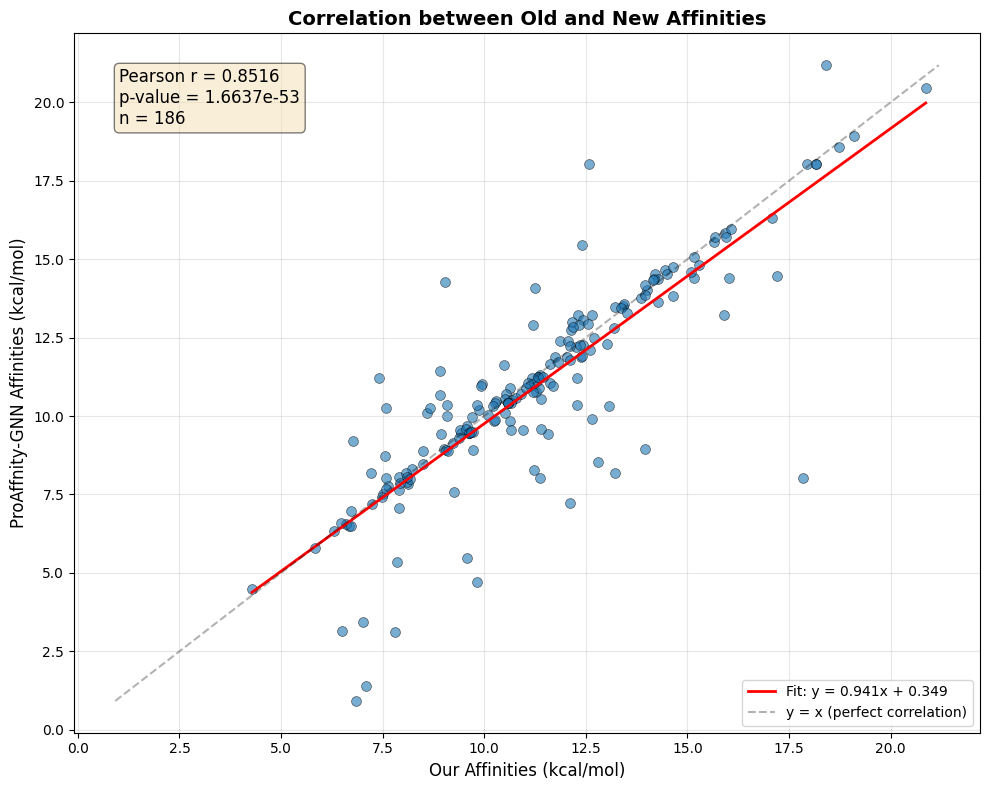

In [7]:
# Compute Pearson correlation coefficient
pearson_r, p_value = stats.pearsonr(old_affinities, new_affinities)

# Compute linear regression for fitting line
slope, intercept = np.polyfit(old_affinities, new_affinities, 1)
fit_line = np.poly1d([slope, intercept])

# Create x values for smooth fitting line
x_fit = np.linspace(min(old_affinities), max(old_affinities), 100)
y_fit = fit_line(x_fit)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(old_affinities, new_affinities, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')

# Add diagonal reference line (perfect correlation)
min_val = min(min(old_affinities), min(new_affinities))
max_val = max(max(old_affinities), max(new_affinities))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='y = x (perfect correlation)')

# Add text box with statistics
textstr = f'Pearson r = {pearson_r:.4f}\np-value = {p_value:.4e}\nn = {len(old_affinities)}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('Our Affinities (kcal/mol)', fontsize=12)
plt.ylabel('ProAffnity-GNN Affinities (kcal/mol)', fontsize=12)
plt.title('Correlation between Old and New Affinities', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Pearson correlation coefficient (r): {pearson_r:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"R² (coefficient of determination): {pearson_r**2:.4f}")

## Update new samples from ProAffnity-GNN database

In [8]:
# get filtered_df rows column 'PDB' in diff_pdbs
new_pagnn_df = pagnn_df[pagnn_df['PDB'].str.lower().isin(diff_pdbs)]
# add column paths by add f'../../PDB/updated_pdb/{pdb_id}.pdb' for each pdb_id in new_pagnn_df['PDB']
new_pagnn_df['paths'] = new_pagnn_df['PDB'].apply(lambda pdb_id: f'../../PDB/updated_pdb/{pdb_id}.pdb')
# check paths in new_pagnn_df exist
for path in new_pagnn_df['paths']:
    if not os.path.exists(path):
        print(f"Path does not exist: {path}")

/var/folders/7y/24kmvp416lg3pshfs_b4qrcm0000gq/T/ipykernel_46684/112494008.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_pagnn_df['paths'] = new_pagnn_df['PDB'].apply(lambda pdb_id: f'../../PDB/updated_pdb/{pdb_id}.pdb')


In [9]:
new_pagnn_df

,PDB,KD(M),affinity,Receptor Chains,Ligand Chains,paths
33,1E3U,1.000000e-06,8.181364,A,C,../../PDB/updated_pdb/1E3U.pdb
42,1ES0,8.000000e-08,9.677067,B,A,../../PDB/updated_pdb/1ES0.pdb
168,1RPQ,3.200000e-08,10.219683,A,W,../../PDB/updated_pdb/1RPQ.pdb
209,1UGH,1.200000e-11,14.891199,E,I,../../PDB/updated_pdb/1UGH.pdb
247,1XX9,3.000000e-09,11.621462,A,"C, D",../../PDB/updated_pdb/1XX9.pdb
...,...,...,...,...,...,...
2160,6AND,7.800000e-09,11.055621,"L, H",K,../../PDB/updated_pdb/6AND.pdb
2161,6ANI,7.800000e-09,11.055621,"L, H",K,../../PDB/updated_pdb/6ANI.pdb
2181,6BRS,1.700000e-06,7.867133,"A, F",E,../../PDB/updated_pdb/6BRS.pdb
2209,6GWC,2.700000e-07,8.956734,"A, B",C,../../PDB/updated_pdb/6GWC.pdb


In [10]:
wt_df

,PDB,KD(M),paths,affinity,Structure Method,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.622671,X-RAY DIFFRACTION,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.658646,X-RAY DIFFRACTION,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,14.567624,X-RAY DIFFRACTION,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,X-RAY DIFFRACTION,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.606704,X-RAY DIFFRACTION,A,D
...,...,...,...,...,...,...,...
12940,3TJH,4.000000e-06,../../PDB/ATLAS/3TJH.pdb,7.364124,X-RAY DIFFRACTION,"A, C","D, E"
12952,3TF7,3.000000e-04,../../PDB/ATLAS/3TF7.pdb,4.806077,X-RAY DIFFRACTION,"A, C","D, E"
12984,4PRI,9.320000e-05,../../PDB/ATLAS/4PRI.pdb,5.498712,X-RAY DIFFRACTION,"A, C","D, E"
12999,3DXA,3.000000e-07,../../PDB/ATLAS/3DXA.pdb,8.898818,X-RAY DIFFRACTION,"A, C","D, E"


In [11]:
# combine wt_df and new_pdb_df to form wt_df
updated_pagnn_wt_df = pd.concat([wt_df, new_pagnn_df], ignore_index=True)
updated_pagnn_wt_df

,PDB,KD(M),paths,affinity,Structure Method,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.622671,X-RAY DIFFRACTION,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.658646,X-RAY DIFFRACTION,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,14.567624,X-RAY DIFFRACTION,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,X-RAY DIFFRACTION,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.606704,X-RAY DIFFRACTION,A,D
...,...,...,...,...,...,...,...
3100,6AND,7.800000e-09,../../PDB/updated_pdb/6AND.pdb,11.055621,NaN,K,"L, H"
3101,6ANI,7.800000e-09,../../PDB/updated_pdb/6ANI.pdb,11.055621,NaN,K,"L, H"
3102,6BRS,1.700000e-06,../../PDB/updated_pdb/6BRS.pdb,7.867133,NaN,E,"A, F"
3103,6GWC,2.700000e-07,../../PDB/updated_pdb/6GWC.pdb,8.956734,NaN,C,"A, B"


In [12]:
updated_pagnn_wt_df[updated_pagnn_wt_df['paths'].str.contains('updated_pdb')]

,PDB,KD(M),paths,affinity,Structure Method,Ligand Chains,Receptor Chains
3027,1E3U,1.000000e-06,../../PDB/updated_pdb/1E3U.pdb,8.181364,NaN,C,A
3028,1ES0,8.000000e-08,../../PDB/updated_pdb/1ES0.pdb,9.677067,NaN,A,B
3029,1RPQ,3.200000e-08,../../PDB/updated_pdb/1RPQ.pdb,10.219683,NaN,W,A
3030,1UGH,1.200000e-11,../../PDB/updated_pdb/1UGH.pdb,14.891199,NaN,I,E
3031,1XX9,3.000000e-09,../../PDB/updated_pdb/1XX9.pdb,11.621462,NaN,"C, D",A
...,...,...,...,...,...,...,...
3100,6AND,7.800000e-09,../../PDB/updated_pdb/6AND.pdb,11.055621,NaN,K,"L, H"
3101,6ANI,7.800000e-09,../../PDB/updated_pdb/6ANI.pdb,11.055621,NaN,K,"L, H"
3102,6BRS,1.700000e-06,../../PDB/updated_pdb/6BRS.pdb,7.867133,NaN,E,"A, F"
3103,6GWC,2.700000e-07,../../PDB/updated_pdb/6GWC.pdb,8.956734,NaN,C,"A, B"


In [21]:
updated_pagnn_wt_df.to_pickle('./saved_tables/updated_unmutant_complex_table.pkl')

In [2]:
import pandas as pd
import pickle
import os

In [3]:
wt_df = pd.read_pickle('./saved_tables/updated_unmutant_complex_table.pkl')
wt_df

,PDB,KD(M),paths,affinity,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.622671,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.658646,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,14.567624,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.606704,A,D
...,...,...,...,...,...,...
3096,5E94,3.000000e-09,../../PDB/updated_pdb/5E94.pdb,11.621462,G,"A, B"
3097,5EIV,2.820000e-05,../../PDB/updated_pdb/5EIV.pdb,6.203861,"I, J, K","A, G, H"
3098,5IBK,7.000000e-08,../../PDB/updated_pdb/5IBK.pdb,9.756143,C,"A, B"
3103,6GWC,2.700000e-07,../../PDB/updated_pdb/6GWC.pdb,8.956734,C,"A, B"


In [8]:
l1 = wt_df[wt_df['paths'].str.contains('updated_pdb')]['PDB'].tolist()
l1[:10], len(l1)

(['1E3U',
  '1ES0',
  '1RPQ',
  '1UGH',
  '1XX9',
  '1XXD',
  '1XXF',
  '1YC0',
  '1ZJD',
  '2GNG'],
 71)

In [9]:
l2 = [pdb.split('.')[0] for pdb in os.listdir('../../curated_db/new_unmut_sttgs_8A') if pdb.endswith('.pkl')]
l2[:10], len(l2)

(['6OAO',
  '3EHU',
  '3C59',
  '3DBH',
  '4KSD',
  '1XXD',
  '1ES0',
  '3DBL',
  '4G6V',
  '3C5T'],
 72)

In [13]:
for pdb in l2:
    if pdb not in l1:
        print(pdb)

1OAU


In [ ]:
wt_df[wt_df['PDB']=='1OAU']

,PDB,KD(M),paths,affinity,Ligand Chains,Receptor Chains


# Convert new pdbs to graphs

In [22]:
import sys
sys.path.append('..')  # Adds parent directory to sys.path
from utils import StructureToHeteroGraph, StructureToTripleGraphs
from tqdm import tqdm
import pickle

In [23]:
new_pdb_df = updated_pagnn_wt_df[updated_pagnn_wt_df['paths'].str.contains('updated_pdb')]

In [24]:
new_pdb_df

,PDB,KD(M),paths,affinity,Structure Method,Ligand Chains,Receptor Chains
3027,1E3U,1.000000e-06,../../PDB/updated_pdb/1E3U.pdb,8.181364,NaN,C,A
3028,1ES0,8.000000e-08,../../PDB/updated_pdb/1ES0.pdb,9.677067,NaN,A,B
3029,1RPQ,3.200000e-08,../../PDB/updated_pdb/1RPQ.pdb,10.219683,NaN,W,A
3030,1UGH,1.200000e-11,../../PDB/updated_pdb/1UGH.pdb,14.891199,NaN,I,E
3031,1XX9,3.000000e-09,../../PDB/updated_pdb/1XX9.pdb,11.621462,NaN,"C, D",A
...,...,...,...,...,...,...,...
3100,6AND,7.800000e-09,../../PDB/updated_pdb/6AND.pdb,11.055621,NaN,K,"L, H"
3101,6ANI,7.800000e-09,../../PDB/updated_pdb/6ANI.pdb,11.055621,NaN,K,"L, H"
3102,6BRS,1.700000e-06,../../PDB/updated_pdb/6BRS.pdb,7.867133,NaN,E,"A, F"
3103,6GWC,2.700000e-07,../../PDB/updated_pdb/6GWC.pdb,8.956734,NaN,C,"A, B"


In [29]:
save_path_hg = '../../curated_db/new_unmut_sthg_8A'
save_path_3g = '../../curated_db/new_unmut_sttgs_8A'
failed_pdbs = []
for ind, row_of_df in tqdm(new_pdb_df.iterrows(),total=len(new_pdb_df)):
    filename = row_of_df["paths"].split("/")[-1].split(".")[0]
    # Check if both output files already exist
    hg_output_path = f'{save_path_hg}/{filename}.pkl'
    tg_output_path = f'{save_path_3g}/{filename}.pkl'
    
    # Process triple graphs if not exists
    if not os.path.exists(tg_output_path):
        sttgs = StructureToTripleGraphs(row_of_df=row_of_df, dist_cutoff=8,root_path='')
        sttgs.process_pdb()
        if len(sttgs.AA_dfs['Receptor']) < 4 or len(sttgs.AA_dfs['Ligand']) < 4:
            print(f"Skipping PDB {filename} due to insufficient residues in Receptor or Ligand.")
            failed_pdbs.append(row_of_df["PDB"])
            continue
        sttgs.get_interface_graph()
        sttgs.get_intra_graphs(use_only_interface=False)
        with open(tg_output_path, 'wb') as f:
            pickle.dump(sttgs, f)
    
    # Process heterograph if not exists
    if not os.path.exists(hg_output_path):
        sthg = StructureToHeteroGraph()
        sthg.process_pdb(row_of_df, root_path='')
        sthg.get_hetero_graph()
        with open(hg_output_path, 'wb') as f:
            pickle.dump(sthg, f)

  0%|          | 0/78 [00:00<?, ?it/s]

Skipping PDB 4R8I due to insufficient residues in Receptor or Ligand.


 40%|███▉      | 31/78 [00:09<00:13,  3.43it/s]

Skipping PDB 4WB2 due to insufficient residues in Receptor or Ligand.


 76%|███████▌  | 59/78 [04:29<05:02, 15.93s/it]

Skipping PDB 3SWP due to insufficient residues in Receptor or Ligand.


 97%|█████████▋| 76/78 [06:38<00:05,  2.87s/it]

Skipping PDB 6ANA due to insufficient residues in Receptor or Ligand.
Skipping PDB 6AND due to insufficient residues in Receptor or Ligand.
Skipping PDB 6ANI due to insufficient residues in Receptor or Ligand.
Skipping PDB 6BRS due to insufficient residues in Receptor or Ligand.


100%|██████████| 78/78 [07:20<00:00,  5.65s/it]


In [13]:
failed_pdbs = ['4R8I','4WB2','3SWP','6ANA','6AND','6ANI','6BRS']
len(failed_pdbs), failed_pdbs 

(7, ['4R8I', '4WB2', '3SWP', '6ANA', '6AND', '6ANI', '6BRS'])

In [17]:
updated_pagnn_wt_df = updated_pagnn_wt_df.drop(columns=['Structure Method'])

In [18]:
updated_pagnn_wt_df[~updated_pagnn_wt_df['PDB'].isin(failed_pdbs)]

,PDB,KD(M),paths,affinity,Ligand Chains,Receptor Chains
0,1A22,9.000000e-10,../../PDB/SKEMPI_v2.0/1A22.pdb,12.622671,A,B
1,1A4Y,5.000000e-16,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.658646,A,B
2,1ACB,1.490000e-12,../../PDB/SKEMPI_v2.0/1ACB.pdb,14.567624,E,I
3,1AHW,3.400000e-09,../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342,"A, B",C
4,1AK4,1.200000e-05,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.606704,A,D
...,...,...,...,...,...,...
3096,5E94,3.000000e-09,../../PDB/updated_pdb/5E94.pdb,11.621462,G,"A, B"
3097,5EIV,2.820000e-05,../../PDB/updated_pdb/5EIV.pdb,6.203861,"I, J, K","A, G, H"
3098,5IBK,7.000000e-08,../../PDB/updated_pdb/5IBK.pdb,9.756143,C,"A, B"
3103,6GWC,2.700000e-07,../../PDB/updated_pdb/6GWC.pdb,8.956734,C,"A, B"


In [19]:
updated_pagnn_wt_df[~updated_pagnn_wt_df['PDB'].isin(failed_pdbs)].to_pickle('./saved_tables/updated_unmutant_complex_table.pkl')

# Download new pdbs

In [20]:
# Create output directory
output_dir = Path('../../PDB/updated_pdb')
output_dir.mkdir(parents=True, exist_ok=True)
# Download all PDBs in diff_pdbs
print(f"Downloading {len(diff_pdbs)} PDB files to {output_dir.resolve()}")

success_count = 0
failed_pdbs = []

for pdb_id in tqdm(sorted(diff_pdbs), desc="Downloading PDBs"):
    success = download_pdb(pdb_id, output_dir)
    if success:
        success_count += 1
    else:
        failed_pdbs.append(pdb_id)
    
    # Small delay to be nice to the server
    time.sleep(0.1)

print(f"\n=== Download Summary ===")
print(f"Total PDBs to download: {len(diff_pdbs)}")
print(f"Successfully downloaded: {success_count}")
print(f"Failed: {len(failed_pdbs)}")

if failed_pdbs:
    print(f"\nFailed PDB IDs:")
    print(failed_pdbs[:20])  # Show first 20
    if len(failed_pdbs) > 20:
        print(f"... and {len(failed_pdbs) - 20} more")


=== Download Summary ===
Total PDBs to download: 78
Successfully downloaded: 78
Failed: 0
